# SisFall Visualisation

This notebook inspects the SisFall files using the same raw-count conversion
assumptions already encoded in the dissertation loader.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CWD = Path.cwd().resolve()
for candidate in (CWD, *CWD.parents):
    if (candidate / "pipeline").exists() and (candidate / "analysis").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repo root from the current working directory.")

for extra_path in (REPO_ROOT, REPO_ROOT / "analysis"):
    extra_str = str(extra_path)
    if extra_str not in sys.path:
        sys.path.insert(0, extra_str)

import notebook_utils as nb_utils

nb_utils.configure_matplotlib()
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [2]:
from pipeline.ingest import load_sisfall

DATASET_PATH = REPO_ROOT / "data" / "raw" / "SISFALL_Dataset" / "SisFall_dataset"
LOAD_FULL_DATASET = False
MAX_FILES = None if LOAD_FULL_DATASET else 60

if not DATASET_PATH.exists():
    raise FileNotFoundError(DATASET_PATH)

df = load_sisfall(DATASET_PATH, max_files=MAX_FILES)
df = nb_utils.add_vector_magnitudes(df)
df["event_code"] = df["session_id"].astype(str).str.split("_").str[0]
df["subject_group"] = df["subject_id"].astype(str).str[:2]

print(f"Loaded {len(df):,} rows from {DATASET_PATH}")
display(df.head())


Loaded 240,399 rows from /home/joels/PycharmProjects/vulnerability_dissertation_clean/data/raw/SISFALL_Dataset/SisFall_dataset


,dataset_name,task_type,subject_id,session_id,timestamp,ax,ay,az,gx,gy,gz,label_raw,label_mapped,placement,sampling_rate_hz,source_file,row_index,acc_magnitude,gyro_magnitude,event_code,subject_group
0,SISFALL,fall,SA01,D01_SA01_R01,0.000,0.650181,-6.846022,-3.786348,-0.021855,-0.611928,-0.427378,ADL,non_fall,waist,200.0,/home/joels/PycharmProjects/vulnerability_diss...,0,7.850298,0.746716,D01,SA
1,SISFALL,fall,SA01,D01_SA01_R01,0.005,0.573689,-6.654793,-3.442134,-0.064350,-0.689633,-0.371527,ADL,non_fall,waist,200.0,/home/joels/PycharmProjects/vulnerability_diss...,1,7.514231,0.785981,D01,SA
2,SISFALL,fall,SA01,D01_SA01_R01,0.010,0.038246,-6.731285,-3.097921,-0.101988,-0.744269,-0.329033,ADL,non_fall,waist,200.0,/home/joels/PycharmProjects/vulnerability_diss...,2,7.410045,0.820122,D01,SA
3,SISFALL,fall,SA01,D01_SA01_R01,0.015,-0.382459,-6.884268,-2.944937,-0.126271,-0.785550,-0.275610,ADL,non_fall,waist,200.0,/home/joels/PycharmProjects/vulnerability_diss...,3,7.497472,0.842018,D01,SA
4,SISFALL,fall,SA01,D01_SA01_R01,0.020,-0.803165,-7.304974,-2.409494,-0.155410,-0.819546,-0.231901,ADL,non_fall,waist,200.0,/home/joels/PycharmProjects/vulnerability_diss...,4,7.733911,0.865786,D01,SA


In [3]:
profile_df = nb_utils.dataset_profile(df)
loader_notes_df = pd.DataFrame({"loader_note": df.attrs.get("loader_notes", [])})
label_raw_df = nb_utils.count_table(df, "label_raw", top_n=10)
label_mapped_df = nb_utils.count_table(df, "label_mapped", top_n=10)
event_code_df = nb_utils.count_table(df, "event_code", top_n=15)
subject_group_df = nb_utils.count_table(df, "subject_group", top_n=10)

display(profile_df)
display(loader_notes_df if not loader_notes_df.empty else pd.DataFrame({"loader_note": ["No loader notes recorded"]}))
display(label_mapped_df)
display(event_code_df)


,metric,value
0,rows,240399.000
1,columns,21.000
2,dataset_name_unique,1.000
3,task_type_unique,1.000
4,subject_id_unique,1.000
5,session_id_unique,60.000
6,source_file_unique,60.000
7,label_raw_unique,1.000
8,label_mapped_unique,1.000
9,sampling_rate_median_hz,200.000


,loader_note
0,Converted gyroscope axes from deg/s to rad/s.
1,SisFall loader converts assumed ADXL345 raw ac...
2,SisFall loader converts assumed ITG3200 raw gy...
3,Column mapping assumption: first 3 numeric cha...


,label_mapped,count,ratio
0,non_fall,240399,1.0


,event_code,count,ratio
0,D05,25000,0.103994
1,D06,25000,0.103994
2,D02,20000,0.083195
3,D03,20000,0.083195
4,D04,20000,0.083195
5,D01,19999,0.083191
6,D07,12000,0.049917
7,D08,12000,0.049917
8,D09,12000,0.049917
9,D10,12000,0.049917


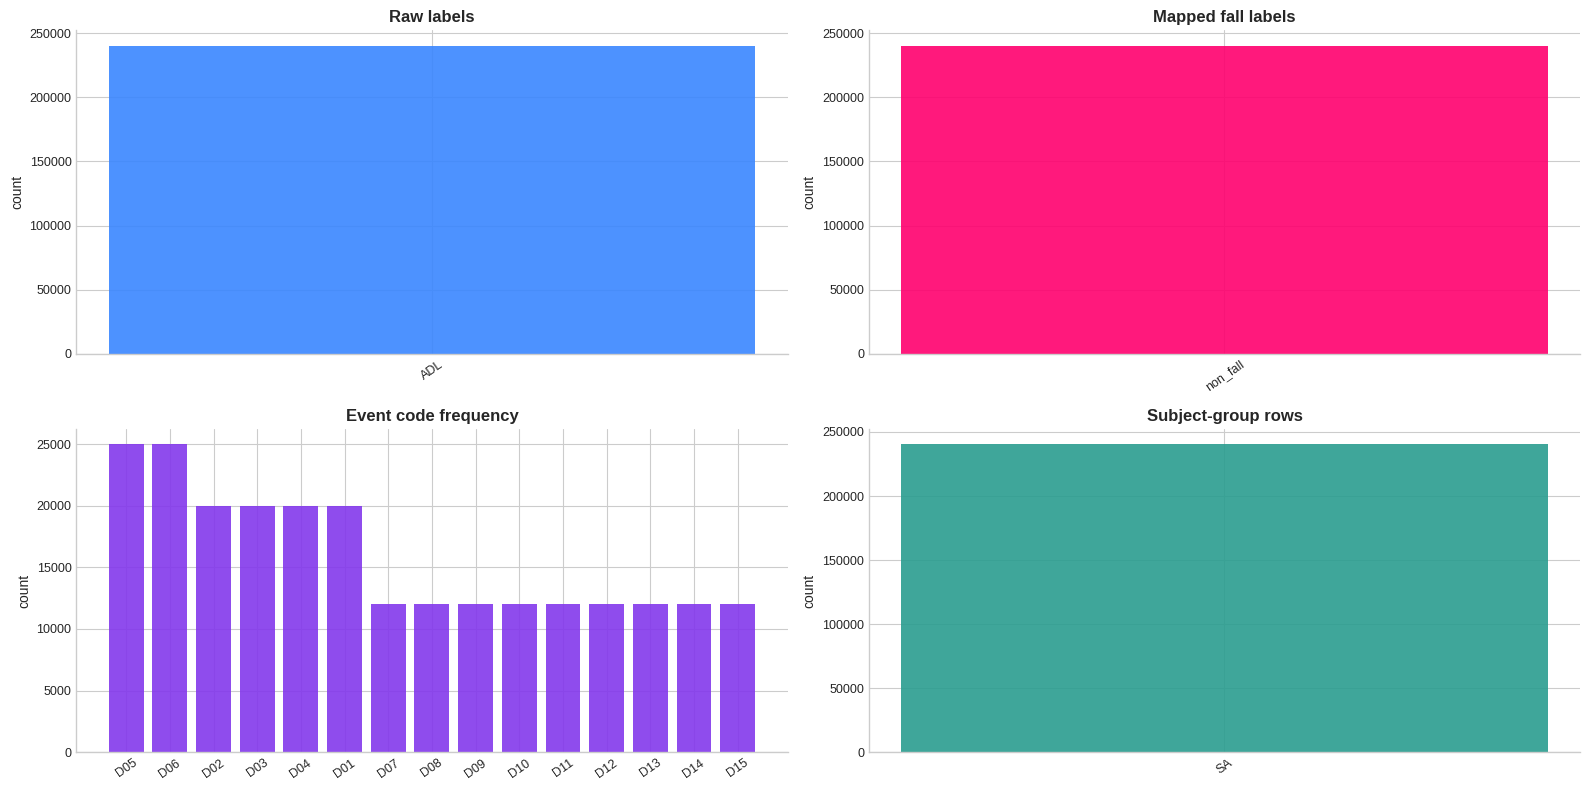

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
nb_utils.plot_count_bars(label_raw_df, "label_raw", ax=axes[0, 0], title="Raw labels", color="#3a86ff")
nb_utils.plot_count_bars(label_mapped_df, "label_mapped", ax=axes[0, 1], title="Mapped fall labels", color="#ff006e")
nb_utils.plot_count_bars(event_code_df, "event_code", ax=axes[1, 0], title="Event code frequency", color="#8338ec")
nb_utils.plot_count_bars(subject_group_df, "subject_group", ax=axes[1, 1], title="Subject-group rows", color="#2a9d8f")
fig.tight_layout()


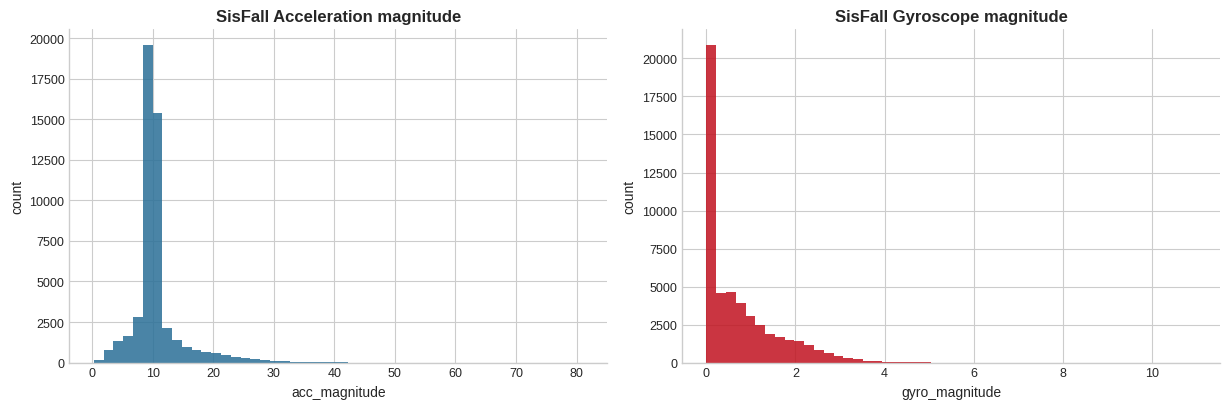

In [5]:
_ = nb_utils.plot_signal_histograms(df, dataset_label="SisFall")


,dataset_name,subject_id,session_id,source_file,start_ts,end_ts,n_rows,label_mapped,label_raw,duration_s
0,SISFALL,SA01,D02_SA01_R01,/home/joels/PycharmProjects/vulnerability_diss...,0.0,99.995,20000,non_fall,ADL,99.995
1,SISFALL,SA01,D03_SA01_R01,/home/joels/PycharmProjects/vulnerability_diss...,0.0,99.995,20000,non_fall,ADL,99.995
2,SISFALL,SA01,D04_SA01_R01,/home/joels/PycharmProjects/vulnerability_diss...,0.0,99.995,20000,non_fall,ADL,99.995
3,SISFALL,SA01,D01_SA01_R01,/home/joels/PycharmProjects/vulnerability_diss...,0.0,99.990,19999,non_fall,ADL,99.990
4,SISFALL,SA01,D05_SA01_R01,/home/joels/PycharmProjects/vulnerability_diss...,0.0,24.995,5000,non_fall,ADL,24.995


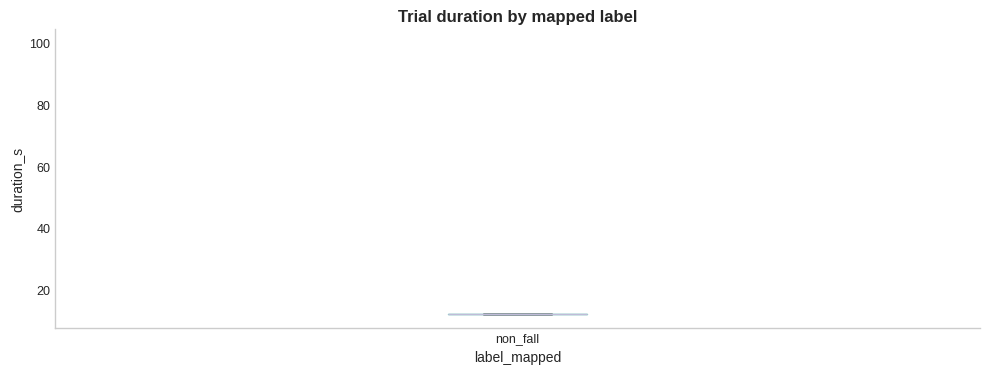

In [6]:
duration_df = nb_utils.session_duration_table(df)
display(duration_df.head())

fig, ax = plt.subplots(figsize=(10, 4))
duration_df.boxplot(column="duration_s", by="label_mapped", ax=ax, grid=False)
ax.set_title("Trial duration by mapped label")
ax.set_xlabel("label_mapped")
ax.set_ylabel("duration_s")
fig.suptitle("")
fig.tight_layout()


,subject_id,session_id,timestamp,ax,ay,az,gx,gy,gz,label_mapped
0,SA01,D02_SA01_R01,0.000,0.267722,-10.211665,0.305967,0.845043,-1.334342,0.326604,non_fall
1,SA01,D02_SA01_R01,0.005,0.458951,-9.905697,-0.688427,0.803762,-1.282134,0.329033,non_fall
2,SA01,D02_SA01_R01,0.010,0.917902,-9.752713,-1.223870,0.704202,-1.178932,0.331461,non_fall
3,SA01,D02_SA01_R01,0.015,1.300362,-9.446746,-1.721067,0.553649,-1.039306,0.313249,non_fall
4,SA01,D02_SA01_R01,0.020,1.682821,-9.484992,-1.606329,0.372742,-0.887538,0.265897,non_fall
5,SA01,D02_SA01_R01,0.025,1.606329,-9.790959,-1.262116,0.196691,-0.735770,0.208832,non_fall
6,SA01,D02_SA01_R01,0.030,1.912297,-10.441140,-0.879657,0.041281,-0.585216,0.157838,non_fall
7,SA01,D02_SA01_R01,0.035,1.912297,-10.785354,-0.038246,-0.083776,-0.437091,0.104416,non_fall
8,SA01,D02_SA01_R01,0.040,2.141772,-11.014829,0.879657,-0.151768,-0.291394,0.041281,non_fall
9,SA01,D02_SA01_R01,0.045,2.409494,-11.053075,1.759313,-0.189406,-0.151768,-0.021855,non_fall


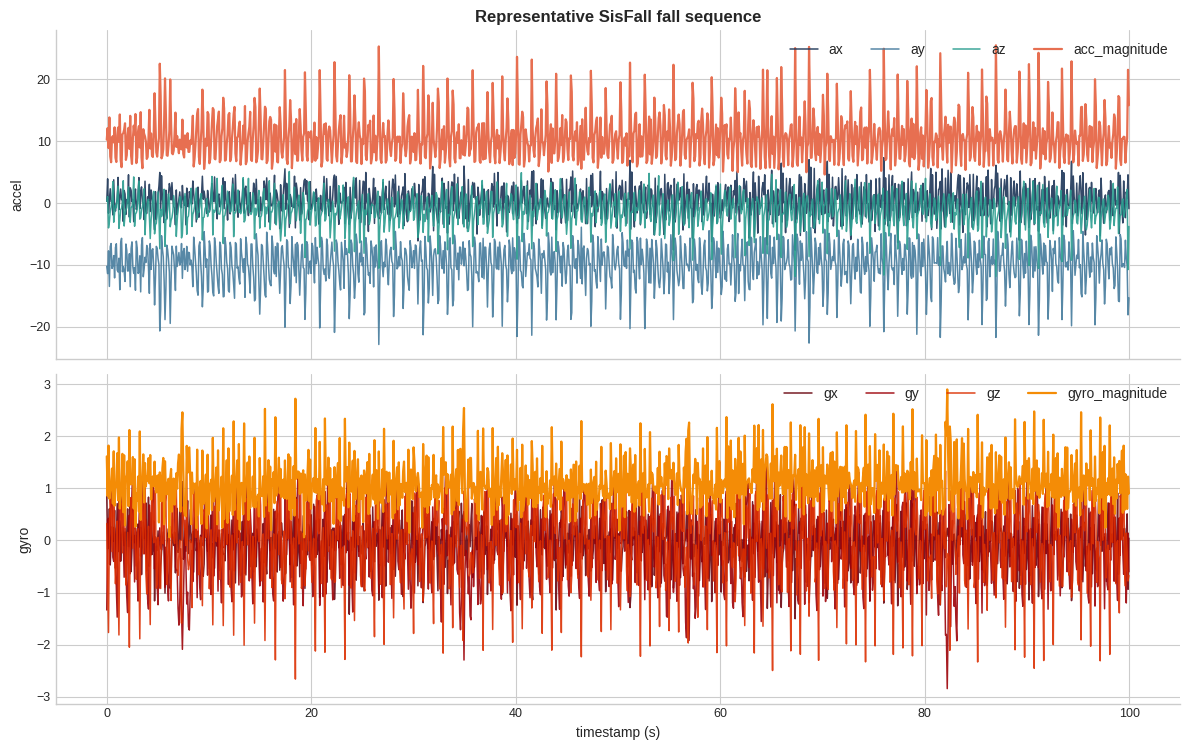

In [7]:
example_seq = nb_utils.pick_representative_sequence(df, preferred_label="fall", min_rows=256)
display(example_seq[["subject_id", "session_id", "timestamp", "ax", "ay", "az", "gx", "gy", "gz", "label_mapped"]].head(12))
_ = nb_utils.plot_sequence_axes(example_seq, title="Representative SisFall fall sequence")
